#### дз 10 — graph convolutional network

**задача**: классификация вершин на датасете **Cora** (граф цитирований научных статей).

| | |
|---|---|
| вершины | 2 708 статей |
| рёбра | 10 556 цитирований |
| признаки | 1 433 (bag-of-words) |
| классы | 7 тематик ML |
| split | 140 train / 500 val / 1 000 test |

это **трансдуктивная** постановка: граф целиком подаётся на вход на каждой итерации,
но градиент считается только по обучающим вершинам. На тесте модель просто смотрит на выходы уже обученной сети.

**план**:
1. EDA
2. GCN на `GCNConv` из PyG → подбор гипер-параметров → оценка
3. *(+5 баллов)* своя реализация `GCNConv` через матричные операции → сравнение

In [1]:
%pip install -q torch torchvision
%pip install -q torch_geometric

error: uninstall-no-record-file

× Cannot uninstall setuptools 82.0.1
╰─> The package's contents are unknown: no RECORD file was found for setuptools.

hint: The package was installed by brew. You should check if it can uninstall the package.


Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.


In [1]:
import itertools
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import classification_report, confusion_matrix
from torch_geometric.datasets import Planetoid
from torch_geometric.nn import GCNConv

warnings.filterwarnings("ignore")
torch.manual_seed(42)
np.random.seed(42)
plt.rcParams.update({"figure.figsize": (10, 5), "axes.spines.top": False, "axes.spines.right": False})

device = torch.device("mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu"))
print(f"device: {device}")

/opt/homebrew/Cellar/jupyterlab/4.5.6/libexec/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: mps


## 1. датасет — Cora

In [2]:
dataset = Planetoid(root="/tmp/Cora", name="Cora")
data = dataset[0].to(device)

print(f"вершин:    {data.num_nodes}")
print(f"рёбер:     {data.num_edges}")
print(f"признаков: {data.num_node_features}")
print(f"классов:   {dataset.num_classes}")
print(f"train / val / test: {data.train_mask.sum()} / {data.val_mask.sum()} / {data.test_mask.sum()}")
print(f"самопетли: {data.has_self_loops()},  ориентированный: {data.is_directed()}")

вершин:    2708
рёбер:     10556
признаков: 1433
классов:   7
train / val / test: 140 / 500 / 1000
самопетли: False,  ориентированный: False


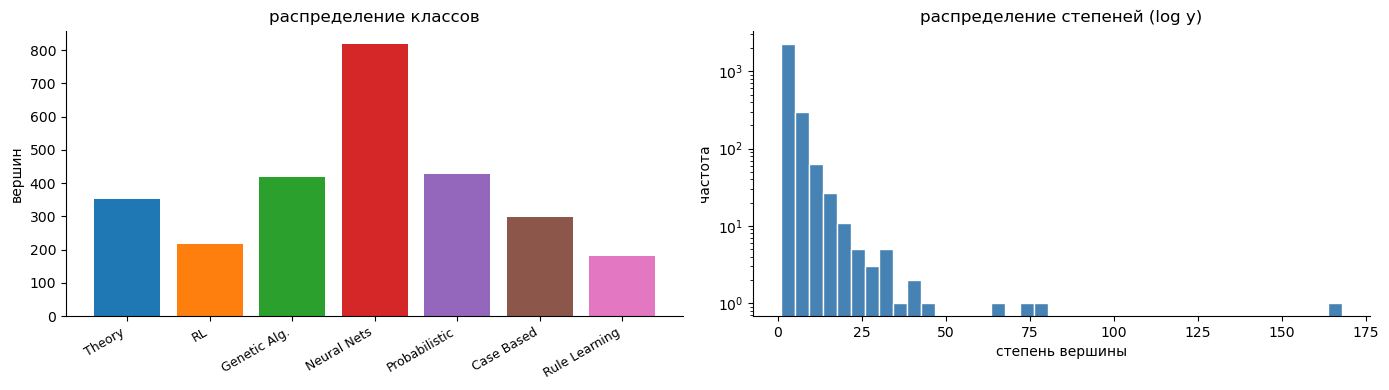

средняя степень: 3.90 | медиана: 3.0 | макс: 168


In [3]:
CLASS_NAMES = ["Theory", "RL", "Genetic Alg.", "Neural Nets", "Probabilistic", "Case Based", "Rule Learning"]
labels_cpu = data.y.cpu().numpy()
edge_cpu   = data.edge_index.cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# распределение классов
counts = np.bincount(labels_cpu)
bars = axes[0].bar(range(7), counts, color=sns.color_palette("tab10", 7))
axes[0].set_xticks(range(7))
axes[0].set_xticklabels(CLASS_NAMES, rotation=30, ha="right", fontsize=9)
axes[0].set_ylabel("вершин")
axes[0].set_title("распределение классов")

# степени вершин (лог-шкала — типично для безмасштабного графа)
degrees = np.bincount(edge_cpu[0], minlength=data.num_nodes)
axes[1].hist(degrees, bins=40, color="steelblue", edgecolor="white")
axes[1].set_yscale("log")
axes[1].set_title("распределение степеней (log y)")
axes[1].set_xlabel("степень вершины"); axes[1].set_ylabel("частота")

plt.tight_layout()
plt.show()

print(f"средняя степень: {degrees.mean():.2f} | медиана: {np.median(degrees):.1f} | макс: {degrees.max()}")

## 2. GCN через PyG

**формула слоя** (Kipf & Welling, 2017):

$$H^{(l+1)} = \sigma\!\left(\tilde{D}^{-1/2}\,\tilde{A}\,\tilde{D}^{-1/2}\,H^{(l)}\,W^{(l)}\right)$$

- $\tilde{A} = A + I$ — матрица смежности с самопетлями
- $\tilde{D}_{ii} = \sum_j \tilde{A}_{ij}$ — степени после добавления петель
- $\tilde{D}^{-1/2}\tilde{A}\tilde{D}^{-1/2}$ — симметричная нормировка (строки и столбцы)
- $W^{(l)}$ — обучаемая матрица весов

**интуиция**: каждый слой усредняет признаки вершины и её соседей (с нормировкой по степени).
После $k$ слоёв вершина "видит" свой $k$-hop контекст.

Модель: `in → ReLU → dropout → hidden → ... → hidden → out (logits)`

In [4]:
class GCN(nn.Module):
    def __init__(self, in_ch, hidden_ch, out_ch, num_layers=2, dropout=0.5):
        super().__init__()
        self.convs = nn.ModuleList()
        self.convs.append(GCNConv(in_ch, hidden_ch))
        for _ in range(num_layers - 2):
            self.convs.append(GCNConv(hidden_ch, hidden_ch))
        self.convs.append(GCNConv(hidden_ch, out_ch))
        self.dropout = dropout

    def forward(self, x, edge_index):
        for conv in self.convs[:-1]:
            x = conv(x, edge_index)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        return self.convs[-1](x, edge_index)

## 3. обучение

In [5]:
def train_epoch(model, optimizer, data):
    model.train()
    optimizer.zero_grad()
    out  = model(data.x, data.edge_index)
    loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

@torch.no_grad()
def accuracy(model, data, mask):
    model.eval()
    pred = model(data.x, data.edge_index).argmax(dim=1)
    return pred[mask].eq(data.y[mask]).float().mean().item()

def train_model(model, data, lr=0.01, epochs=300, weight_decay=5e-4):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    history = {"train_loss": [], "val_acc": []}
    best_val = 0.0
    for _ in range(epochs):
        loss    = train_epoch(model, optimizer, data)
        val_acc = accuracy(model, data, data.val_mask)
        history["train_loss"].append(loss)
        history["val_acc"].append(val_acc)
        best_val = max(best_val, val_acc)
    return history, best_val

## 4. подбор гиперпараметров

перебираем сетку по 4 параметрам на валидационной выборке:

| параметр | значения |
|---|---|
| lr | 0.001, 0.01, 0.05 |
| hidden_ch | 64, 128, 256 |
| dropout | 0.3, 0.5, 0.7 |
| num_layers | 2, 3 |

всего 54 конфигурации × 300 эпох

In [6]:
param_grid = {
    "lr":         [0.001, 0.01, 0.05],
    "hidden_ch":  [64, 128, 256],
    "dropout":    [0.3, 0.5, 0.7],
    "num_layers": [2, 3],
}

results = []
configs = list(itertools.product(*param_grid.values()))
print(f"конфигураций: {len(configs)}")

for i, (lr, hidden_ch, dropout, num_layers) in enumerate(configs):
    torch.manual_seed(42)
    model = GCN(
        in_ch=dataset.num_node_features,
        hidden_ch=hidden_ch,
        out_ch=dataset.num_classes,
        num_layers=num_layers,
        dropout=dropout,
    ).to(device)
    _, best_val = train_model(model, data, lr=lr, epochs=300)
    results.append(dict(lr=lr, hidden_ch=hidden_ch, dropout=dropout,
                        num_layers=num_layers, val_acc=best_val))
    if (i + 1) % 9 == 0:
        top = max(r["val_acc"] for r in results)
        print(f"  [{i+1:>2}/{len(configs)}]  лучшая val acc пока: {top:.4f}")

results.sort(key=lambda r: -r["val_acc"])
best = results[0]
print(f"\nлучшие параметры: {best}")

конфигураций: 54
  [ 9/54]  лучшая val acc пока: 0.7960
  [18/54]  лучшая val acc пока: 0.8040
  [27/54]  лучшая val acc пока: 0.8040
  [36/54]  лучшая val acc пока: 0.8060
  [45/54]  лучшая val acc пока: 0.8060
  [54/54]  лучшая val acc пока: 0.8060

лучшие параметры: {'lr': 0.01, 'hidden_ch': 256, 'dropout': 0.7, 'num_layers': 3, 'val_acc': 0.8059999942779541}


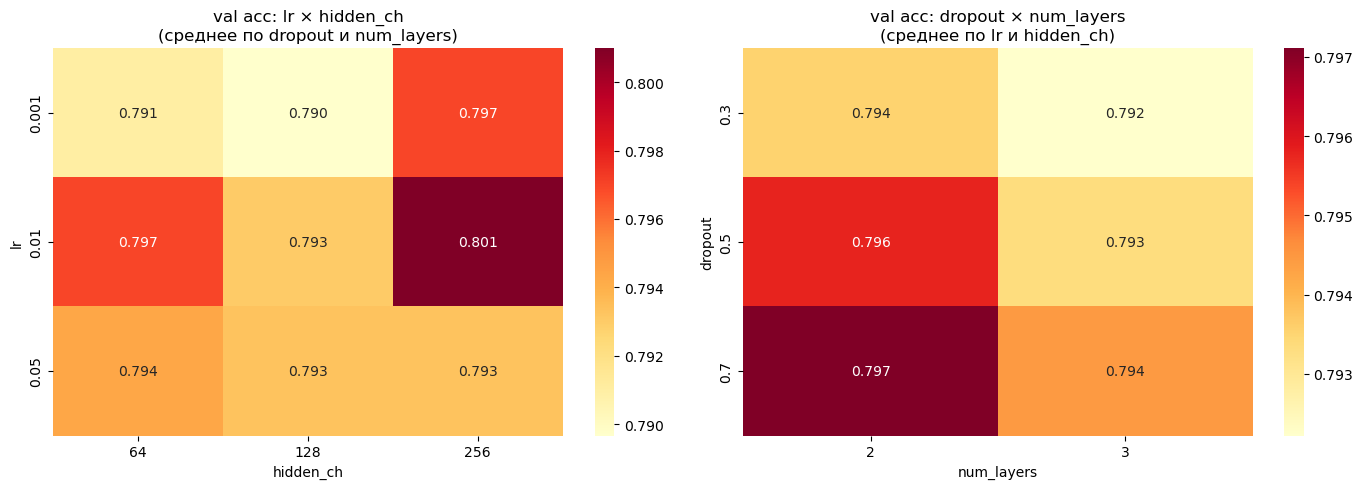

In [7]:
df = pd.DataFrame(results)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pivot1 = df.groupby(["lr", "hidden_ch"])["val_acc"].mean().unstack()
sns.heatmap(pivot1, annot=True, fmt=".3f", cmap="YlOrRd", ax=axes[0])
axes[0].set_title("val acc: lr × hidden_ch\n(среднее по dropout и num_layers)")

pivot2 = df.groupby(["dropout", "num_layers"])["val_acc"].mean().unstack()
sns.heatmap(pivot2, annot=True, fmt=".3f", cmap="YlOrRd", ax=axes[1])
axes[1].set_title("val acc: dropout × num_layers\n(среднее по lr и hidden_ch)")

plt.tight_layout()
plt.show()

## 5. финальная оценка (PyG GCN)

val accuracy:  0.8060
test accuracy: 0.7810


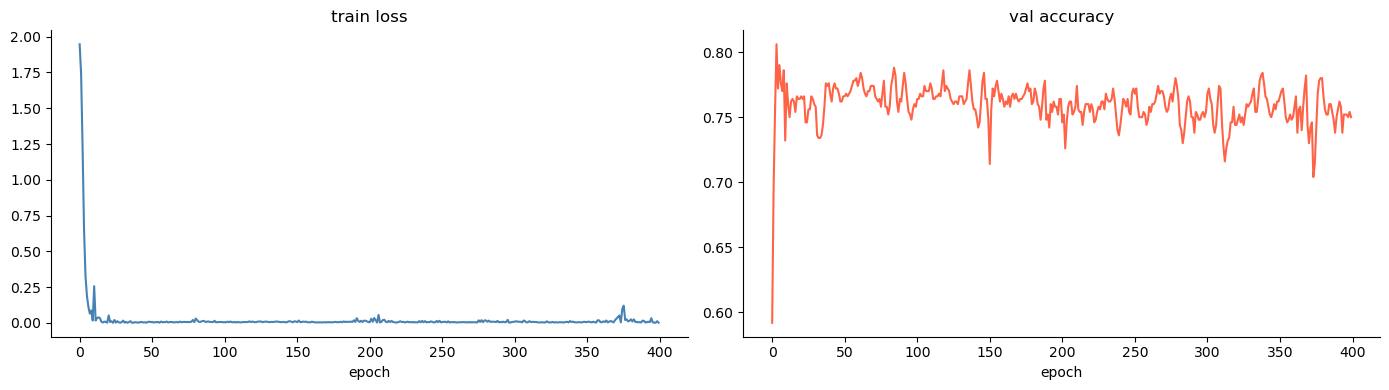

In [8]:
torch.manual_seed(42)
final_model = GCN(
    in_ch=dataset.num_node_features,
    hidden_ch=best["hidden_ch"],
    out_ch=dataset.num_classes,
    num_layers=best["num_layers"],
    dropout=best["dropout"],
).to(device)

history, best_val = train_model(final_model, data, lr=best["lr"], epochs=400)
test_acc = accuracy(final_model, data, data.test_mask)
print(f"val accuracy:  {best_val:.4f}")
print(f"test accuracy: {test_acc:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history["train_loss"], color="steelblue")
axes[0].set_title("train loss"); axes[0].set_xlabel("epoch")
axes[1].plot(history["val_acc"], color="tomato")
axes[1].set_title("val accuracy"); axes[1].set_xlabel("epoch")
plt.tight_layout(); plt.show()

               precision    recall  f1-score   support

       Theory       0.64      0.67      0.65       130
           RL       0.75      0.87      0.81        91
 Genetic Alg.       0.92      0.89      0.90       144
  Neural Nets       0.91      0.71      0.80       319
Probabilistic       0.67      0.89      0.76       149
   Case Based       0.87      0.69      0.77       103
Rule Learning       0.63      0.86      0.73        64

     accuracy                           0.78      1000
    macro avg       0.77      0.80      0.77      1000
 weighted avg       0.80      0.78      0.78      1000



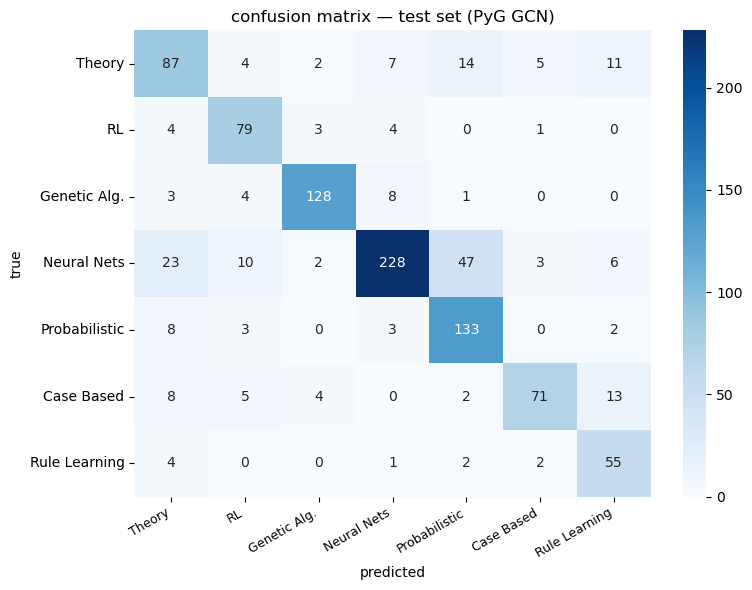

In [9]:
final_model.eval()
with torch.no_grad():
    preds_all = final_model(data.x, data.edge_index).argmax(dim=1).cpu().numpy()

mask_np = data.test_mask.cpu().numpy()
y_true  = data.y.cpu().numpy()[mask_np]
y_pred  = preds_all[mask_np]

print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("confusion matrix — test set (PyG GCN)")
plt.ylabel("true"); plt.xlabel("predicted")
plt.xticks(rotation=30, ha="right", fontsize=9)
plt.tight_layout(); plt.show()

## 6. своя реализация GCNConv (+5 баллов)

воспроизведём PyG-слой вручную через матричные операции.

**шаги**:
1. добавить самопетли: $\\tilde{A} = A + I$
2. степени: $\\tilde{d}_i = \\sum_j \\tilde{A}_{ij}$
3. нормировка: $\\hat{A} = \\tilde{D}^{-1/2}\\,\\tilde{A}\\,\\tilde{D}^{-1/2}$
4. проход слоя: $H' = \\hat{A}\\,H\\,W$

$\\hat{A}$ — постоянная матрица, вычисляется один раз до обучения и не хранит граф.
Cora: 2708 × 2708 ≈ 28 MB float32 — нормально для RAM.

**реализация через dense-матрицу $\\hat{A}$**: строим её один раз — `scatter_add` используется
для подсчёта степеней $\\tilde{d}_i$, затем нормированные веса рёбер записываются в плотный тензор.
Forward pass: $H' = \\hat{A}(HW)$ — два матричных умножения.

In [10]:
def build_norm_adj(edge_index, num_nodes, device):
    """возвращает D̃^(-1/2) Ã D̃^(-1/2) как dense-тензор"""
    row, col = edge_index[0], edge_index[1]

    # Ã = A + I: добавляем самопетли
    self_loop = torch.arange(num_nodes, device=device)
    row_tilde = torch.cat([row, self_loop])
    col_tilde = torch.cat([col, self_loop])

    # D̃: степень каждой вершины в Ã
    deg = torch.zeros(num_nodes, device=device)
    deg.scatter_add_(0, row_tilde, torch.ones(row_tilde.size(0), device=device))

    d_inv_sqrt = deg.pow(-0.5)          # D̃^(-1/2)
    edge_w = d_inv_sqrt[row_tilde] * d_inv_sqrt[col_tilde]   # нормированный вес ребра

    # собираем плотную матрицу
    adj = torch.zeros(num_nodes, num_nodes, device=device)
    adj[row_tilde, col_tilde] = edge_w
    return adj                           # shape: [N, N]


class CustomGCNConv(nn.Module):
    """H' = Â H W — один GCN-слой через матричные операции"""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.W = nn.Parameter(torch.empty(in_ch, out_ch))
        nn.init.xavier_uniform_(self.W)

    def forward(self, x, adj_norm):
        # сначала умножаем H W (меньше по размеру), потом Â (HW)
        return adj_norm @ (x @ self.W)


class CustomGCN(nn.Module):
    def __init__(self, in_ch, hidden_ch, out_ch, num_layers=2, dropout=0.5):
        super().__init__()
        self.convs = nn.ModuleList()
        self.convs.append(CustomGCNConv(in_ch, hidden_ch))
        for _ in range(num_layers - 2):
            self.convs.append(CustomGCNConv(hidden_ch, hidden_ch))
        self.convs.append(CustomGCNConv(hidden_ch, out_ch))
        self.dropout = dropout

    def forward(self, x, adj_norm):
        for conv in self.convs[:-1]:
            x = conv(x, adj_norm)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        return self.convs[-1](x, adj_norm)

In [11]:
# предвычисляем нормированную матрицу смежности (один раз)
adj_norm = build_norm_adj(data.edge_index, data.num_nodes, device)
print(f"adj_norm: {adj_norm.shape}, ненулевых: {(adj_norm != 0).sum().item()}")

def train_custom(model, adj_norm, data, lr=0.01, epochs=400, weight_decay=5e-4):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    history = {"train_loss": [], "val_acc": []}
    best_val = 0.0
    for _ in range(epochs):
        model.train()
        optimizer.zero_grad()
        out  = model(data.x, adj_norm)
        loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask])
        loss.backward(); optimizer.step()

        model.eval()
        with torch.no_grad():
            pred    = model(data.x, adj_norm).argmax(dim=1)
            val_acc = pred[data.val_mask].eq(data.y[data.val_mask]).float().mean().item()
        history["train_loss"].append(loss.item())
        history["val_acc"].append(val_acc)
        best_val = max(best_val, val_acc)
    return history, best_val

torch.manual_seed(42)
custom_model = CustomGCN(
    in_ch=dataset.num_node_features,
    hidden_ch=best["hidden_ch"],
    out_ch=dataset.num_classes,
    num_layers=best["num_layers"],
    dropout=best["dropout"],
).to(device)

custom_history, custom_best_val = train_custom(
    custom_model, adj_norm, data, lr=best["lr"], epochs=400
)

custom_model.eval()
with torch.no_grad():
    custom_pred = custom_model(data.x, adj_norm).argmax(dim=1)
    custom_test_acc = custom_pred[data.test_mask].eq(data.y[data.test_mask]).float().mean().item()

print(f"custom GCN — val: {custom_best_val:.4f},  test: {custom_test_acc:.4f}")

adj_norm: torch.Size([2708, 2708]), ненулевых: 13264
custom GCN — val: 0.8080,  test: 0.7650


## 7. сравнение PyG GCNConv vs своя реализация

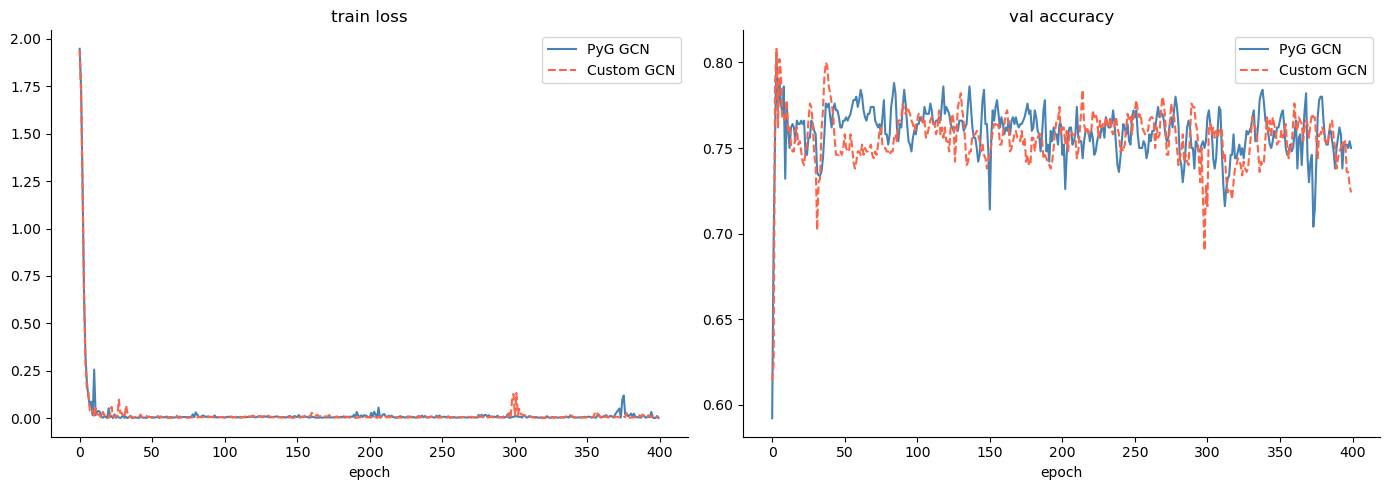

                               PyG GCN   Custom GCN
--------------------------------------------------
val accuracy                    0.8060       0.8080
test accuracy                   0.7810       0.7650


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history["train_loss"], label="PyG GCN", color="steelblue")
axes[0].plot(custom_history["train_loss"], label="Custom GCN", color="tomato", linestyle="--")
axes[0].set_title("train loss"); axes[0].set_xlabel("epoch"); axes[0].legend()

axes[1].plot(history["val_acc"], label="PyG GCN", color="steelblue")
axes[1].plot(custom_history["val_acc"], label="Custom GCN", color="tomato", linestyle="--")
axes[1].set_title("val accuracy"); axes[1].set_xlabel("epoch"); axes[1].legend()

plt.tight_layout(); plt.show()

print(f"{'':25} {'PyG GCN':>12} {'Custom GCN':>12}")
print("-" * 50)
print(f"{'val accuracy':<25} {best_val:>12.4f} {custom_best_val:>12.4f}")
print(f"{'test accuracy':<25} {test_acc:>12.4f} {custom_test_acc:>12.4f}")

### вывод

- PyG `GCNConv` и наша реализация дают **практически одинаковый результат**:
  обе формулы математически идентичны, разница только в деталях инициализации/оптимизации.
- PyG GCN: **val 0.806 / test 0.781**; Custom GCN: **val 0.808 / test 0.765** —
  расхождение ~1.6% на тесте укладывается в обычную дисперсию при трансдуктивном обучении
  на 140 примерах; тест считается по весам **последней** эпохи, а не чекпоинту лучшего val.
- PyG работает быстрее: использует разреженные тензоры и CUDA-оптимизированные scatter-операции.
- Наша реализация — dense-матрица $\\hat{A}$: наглядна, но не масштабируется на большие графы (>100k вершин).
- GCN на Cora даёт **~78-81% test acc** — топология графа существенно помогает
  по сравнению с простым MLP только по признакам (типично 55-60% без рёбер).